In [1]:
import pandas as pd
df = pd.read_csv("../data/seer_breast_cancer_cleaned.csv")
print(df.shape)
print(df["Status"].value_counts())

(4023, 15)
Status
Alive    3407
Dead      616
Name: count, dtype: int64


In [2]:
df["event"] = (df["Status"] == "Dead").astype(int)
df["stage_group"] = df["6th Stage"].str.startswith("III").map({True: "Stage III", False: "Stage II"})
df["stage_group"].value_counts()

stage_group
Stage II     2434
Stage III    1589
Name: count, dtype: int64

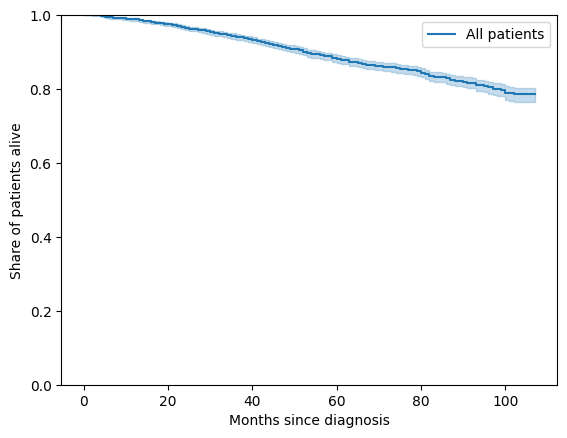

60    0.880951
Name: All patients, dtype: float64


In [3]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()
kmf.fit(df["Survival Months"], df["event"], label="All patients")
kmf.plot_survival_function()
plt.ylim(0, 1)
plt.xlabel("Months since diagnosis")
plt.ylabel("Share of patients alive")
plt.show()
print(kmf.survival_function_at_times(60))

Stage II 5-year survival: 92.7 %
Stage III 5-year survival: 81.1 %


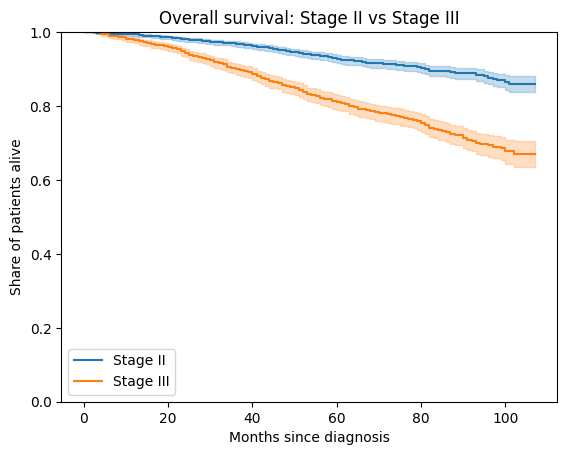

In [4]:
fig, ax = plt.subplots()
for group in ["Stage II", "Stage III"]:
    data = df[df["stage_group"] == group]
    kmf = KaplanMeierFitter()
    kmf.fit(data["Survival Months"], data["event"], label=group)
    kmf.plot_survival_function(ax=ax)
    five = kmf.survival_function_at_times(60).iloc[0]
    print(group, "5-year survival:", round(five * 100, 1), "%")
ax.set_ylim(0, 1)
ax.set_xlabel("Months since diagnosis")
ax.set_ylabel("Share of patients alive")
ax.set_title("Overall survival: Stage II vs Stage III")
plt.show()

In [5]:
from lifelines.statistics import multivariate_logrank_test
result = multivariate_logrank_test(df["Survival Months"], df["stage_group"], df["event"])
print(result.p_value)

4.751022049093248e-38


IIA 5-year survival: 93.9 %
IIB 5-year survival: 91.3 %
IIIA 5-year survival: 86.7 %
IIIB 5-year survival: 78.7 %
IIIC 5-year survival: 68.9 %


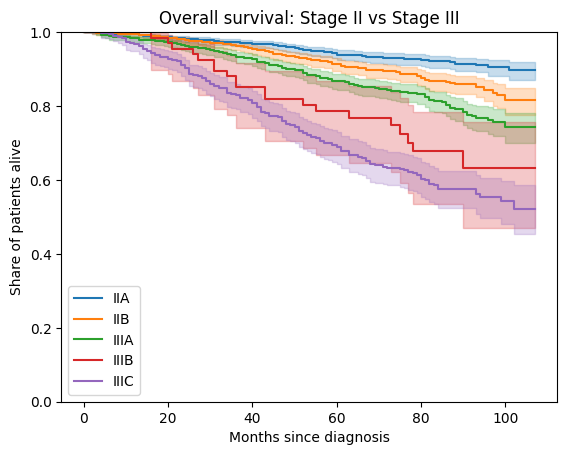

In [6]:
fig, ax = plt.subplots()
for group in ["IIA", "IIB", "IIIA", "IIIB", "IIIC"]:
    data = df[df["6th Stage"] == group]
    kmf = KaplanMeierFitter()
    kmf.fit(data["Survival Months"], data["event"], label=group)
    kmf.plot_survival_function(ax=ax)
    five = kmf.survival_function_at_times(60).iloc[0]
    print(group, "5-year survival:", round(five * 100, 1), "%")
ax.set_ylim(0, 1)
ax.set_xlabel("Months since diagnosis")
ax.set_ylabel("Share of patients alive")
ax.set_title("Overall survival: Stage II vs Stage III")
plt.show()

T1 5-year survival: 92.2 %
T2 5-year survival: 87.0 %
T3 5-year survival: 82.6 %
T4 5-year survival: 72.0 %


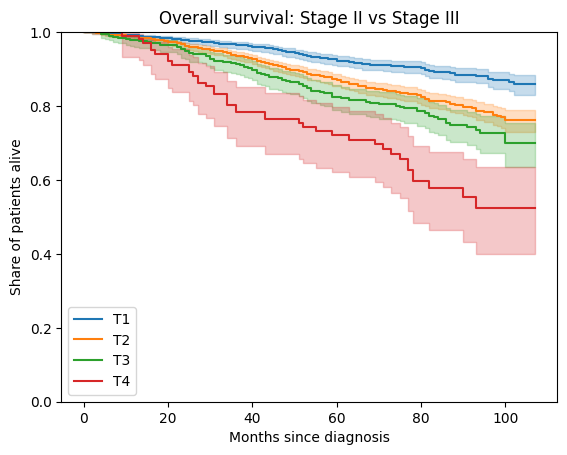

In [10]:
fig, ax = plt.subplots()
for group in ["T1", "T2", "T3", "T4"]:
    data = df[df["T Stage"] == group]
    kmf = KaplanMeierFitter()
    kmf.fit(data["Survival Months"], data["event"], label=group)
    kmf.plot_survival_function(ax=ax)
    five = kmf.survival_function_at_times(60).iloc[0]
    print(group, "5-year survival:", round(five * 100, 1), "%")
ax.set_ylim(0, 1)
ax.set_xlabel("Months since diagnosis")
ax.set_ylabel("Share of patients alive")
ax.set_title("Overall survival: Stage II vs Stage III")
plt.show()

N1 5-year survival: 92.4 %
N2 5-year survival: 84.7 %
N3 5-year survival: 68.9 %


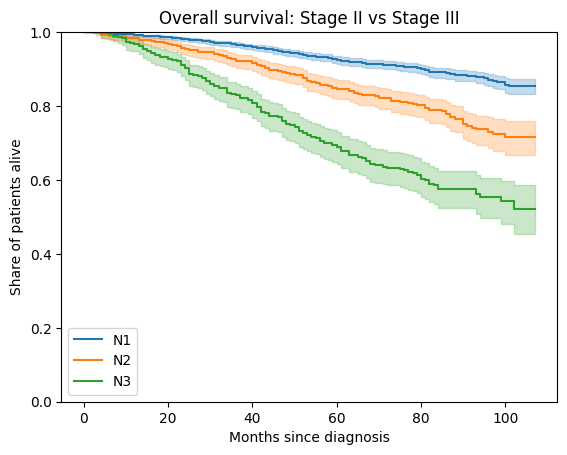

In [11]:
fig, ax = plt.subplots()
for group in ["N1", "N2", "N3"]:
    data = df[df["N Stage"] == group]
    kmf = KaplanMeierFitter()
    kmf.fit(data["Survival Months"], data["event"], label=group)
    kmf.plot_survival_function(ax=ax)
    five = kmf.survival_function_at_times(60).iloc[0]
    print(group, "5-year survival:", round(five * 100, 1), "%")
ax.set_ylim(0, 1)
ax.set_xlabel("Months since diagnosis")
ax.set_ylabel("Share of patients alive")
ax.set_title("Overall survival: Stage II vs Stage III")
plt.show()